In [40]:
using CairoMakie

include("./experiment_simplified_linear_attention.jl")
include("./theory_ridgeless.jl")

theorem_limit (generic function with 1 method)

In [ ]:
# parameters

# theory
alphas = [0.5, 1.0, 2.0, 4.0]
tau = 3.0
sigma = 0.01
tmax = 30

# experiment
D = 500
lambda = 1e-5
seed = 42
n_test = 2000
n_trials = 5

prec = 1512

1512

In [42]:
# main
generalization_error_theory = zeros(length(alphas), tmax + 1)
generalization_error_experiment = zeros(length(alphas), n_trials, tmax + 1)

@time for (i, alpha) in enumerate(alphas)
    Et, b, h, c = theory_Et_direct(alpha, tau, sigma, tmax; prec=prec)
    generalization_error_theory[i, :] .= Float64.(Et)
end

indexes = CartesianIndices((eachindex(alphas), 1:n_trials))

@time Threads.@threads for I in indexes
    alpha_idx, n_trial = Tuple(I)
    alpha = alphas[alpha_idx]
    result = run_experiment(
        D = D,
        α = alpha,
        τ = tau,
        σ = sigma,
        λ = lambda,
        n_test = n_test,
        t_max = tmax,
        seed = seed + 100 * alpha_idx + n_trial,
    )
    generalization_error_experiment[alpha_idx, n_trial, :] .= result.gen_error
end

  0.231897 seconds (1.05 M allocations: 123.350 MiB, 66.71% compilation time)
166.517119 seconds (13.99 M allocations: 621.086 GiB, 11.98% gc time, 0.15% compilation time)


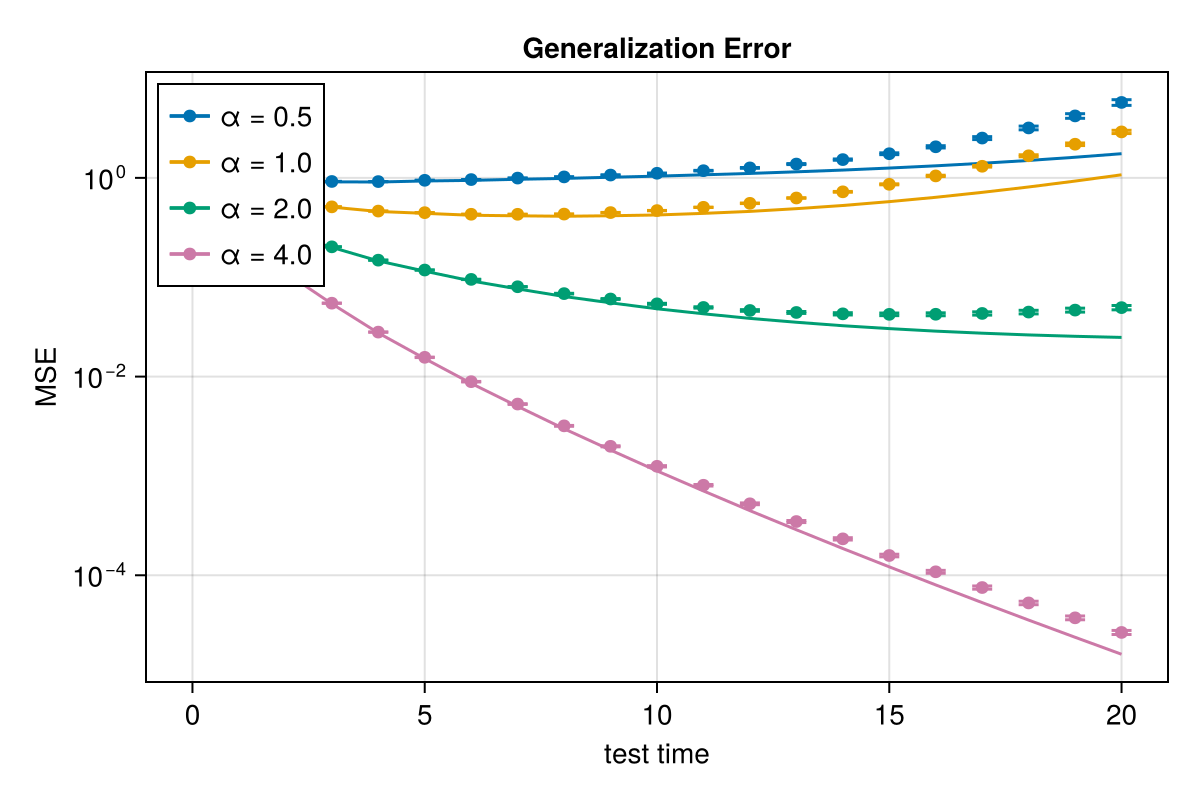

CairoMakie.Screen{IMAGE}


In [49]:
fig = Figure(size=(600, 400))
#limits = (nothing, nothing, 0.0, 3.0)
ax = Axis(fig[1, 1], 
    title="Generalization Error", xlabel="test time", ylabel="MSE", 
    yscale=log10,)
    #limits=limits)

for (i, alpha) in enumerate(alphas)
    lines!(ax, 0:tmax, generalization_error_theory[i, :], label="α = $alpha")

    # generalization_error_experiment[i, :, :] has shape (n_trials, tmax+1)
    generalization_error_experiment_mean = vec(mean(generalization_error_experiment[i, :, :], dims=1))
    generalization_error_experiment_se = vec(std(generalization_error_experiment[i, :, :], dims=1) ./ sqrt(n_trials))

    errorbars!(
        ax,
        0:tmax,
        generalization_error_experiment_mean,
        generalization_error_experiment_se,
        whiskerwidth=10.0,
        label="α = $alpha"
    )
    scatter!(ax, 0:tmax, generalization_error_experiment_mean, label="α = $alpha")
end

axislegend(ax, merge=true, position=:lt)

display(fig)